# house pricing predictore

In [6]:
# Basic data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_california_housing

# Train/test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Pipelines
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## get data

In [11]:

housing = fetch_california_housing(as_frame=True)

df_copy = housing.data.copy()
df_copy["MedHouseVal"] = housing.target
df_copy["price"] = df_copy["MedHouseVal"] * 100000

df_copy.head()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,342200.0


## dataset visualisation

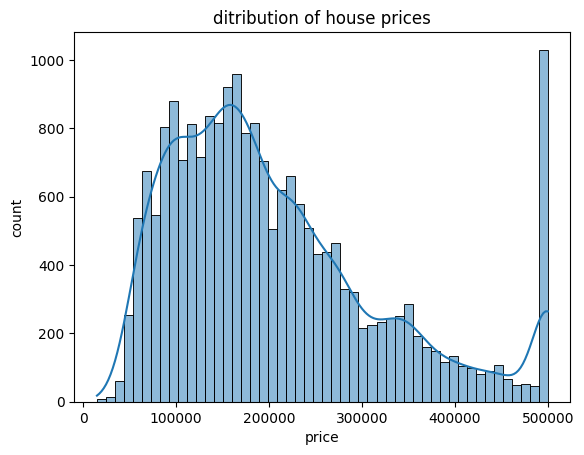

In [12]:
plt.Figure(figsize=(8,5))
sns.histplot(df_copy["price"],bins=50,kde=True)
plt.title("ditribution of house prices")
plt.xlabel("price")
plt.ylabel("count")
plt.show()

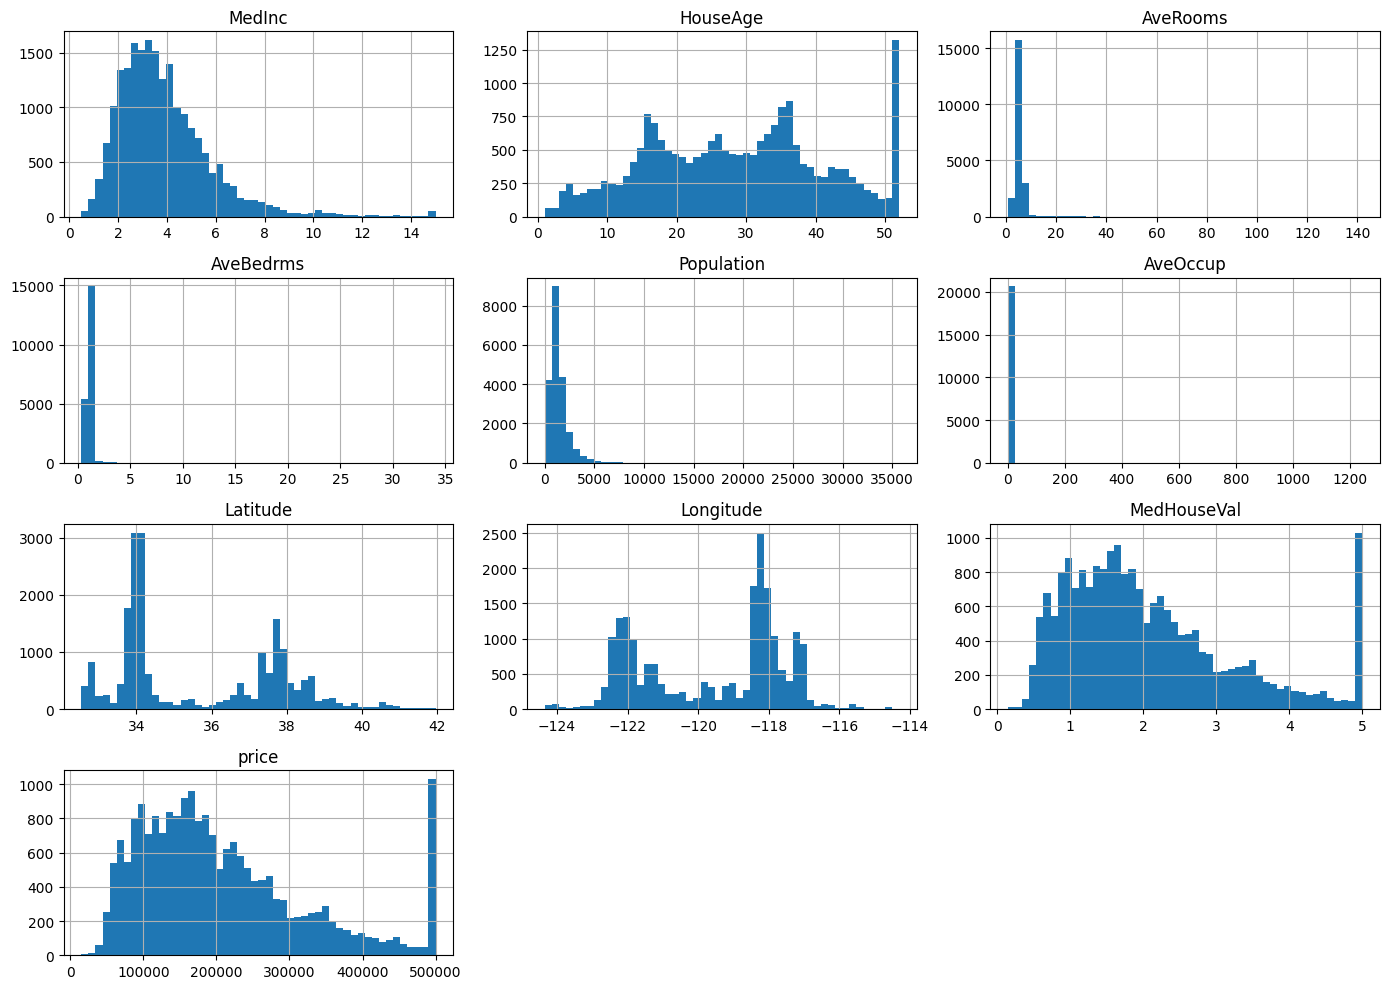

In [13]:
df_copy.hist(figsize=(14,10),bins=50)
plt.tight_layout()
plt.show()

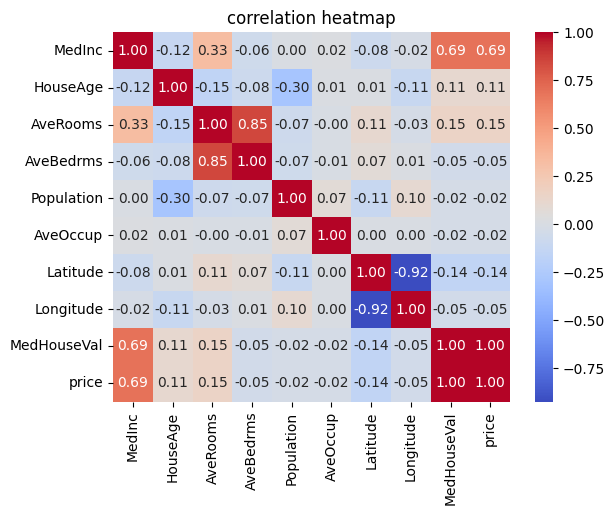

In [14]:
plt.Figure(figsize=(10,7))
sns.heatmap(df_copy.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("correlation heatmap")
plt.show()

## data cleaning

In [16]:
f'missing values : {df_copy.isnull().sum()}'

'missing values : MedInc         0\nHouseAge       0\nAveRooms       0\nAveBedrms      0\nPopulation     0\nAveOccup       0\nLatitude       0\nLongitude      0\nMedHouseVal    0\nprice          0\ndtype: int64'

In [18]:
x = df_copy.drop(["MedHouseVal","price"],axis=1)
y = df_copy["price"]

In [19]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# models training

### linear regression

In [20]:
model1 = LinearRegression()
model1.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_pred = model1.predict(x_test)

### evaluation

MAE: $53,320.01
RMSE: $74,558.14
R² Score: 0.5758
R² as percentage: 57.58%


,Actual Price,Predicted Price,Difference
20046,47700.0,71912.284160,-24212.284160
3024,45800.0,176401.657066,-130601.657066
15663,500001.0,270965.883343,229035.116657
20484,218600.0,283892.593018,-65292.593018
9814,278000.0,260465.725181,17534.274819
13311,158700.0,201175.367325,-42475.367325
7113,198200.0,264550.004938,-66350.004938
7668,157500.0,216875.532129,-59375.532129
18246,340000.0,274074.644114,65925.355886
5723,446600.0,391561.472503,55038.527497


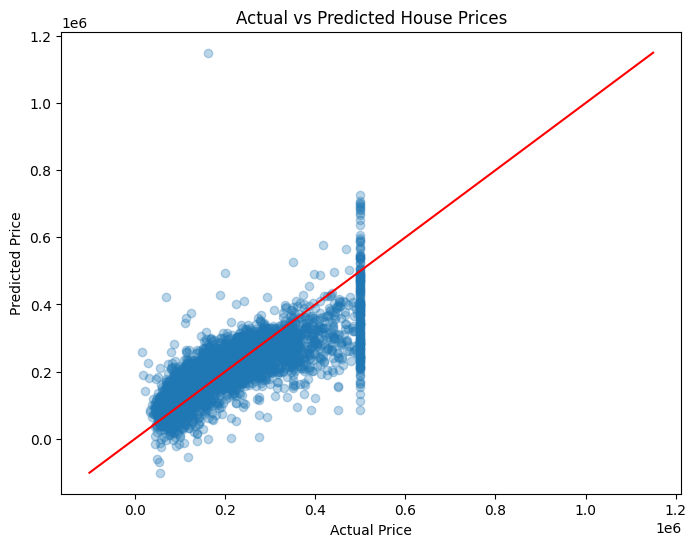

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"R² as percentage: {r2 * 100:.2f}%")

results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred,
    "Difference": y_test - y_pred
})

display(results.head(10))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)

min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())
plt.plot([min_price, max_price], [min_price, max_price], color="red")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## random forest

In [26]:
model2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model2.fit(x_train,y_train)
model2_pred = model2.predict(x_test)


In [27]:
mae_rf = mean_absolute_error(y_test,model2_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test,model2_pred))
r2_rf = r2_score(y_test,model2_pred)

In [30]:
f'MAE : ${mae_rf:,.2f}'

'MAE : $32,811.68'

In [31]:
f'RMSE : ${rmse_rf:,.2f}'

'RMSE : $50,710.38'

In [32]:
f'R² : ${r2_rf:,.2f}'

'R² : $0.80'

In [34]:

f'R² as percentage : ${r2_rf * 100:.2f}%'

'R² as percentage : $80.38%'